# Sandeep Parupalli  
**University of the Cumberlands**  
**2026 Spring - Advanced Big Data and Data Mining (MSCS-634-B01)**  
**Lab 1: Data Visualization, Preprocessing, and Statistical Analysis**

This notebook demonstrates data loading, visualization, preprocessing, and statistical analysis using a retail sales dataset selected for this lab.


## Step 1: Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('retail_sales_data.csv', parse_dates=['Date'])
df.head()

,Date,Product_Category,Region,Units_Sold,Unit_Price,Discount_Percent,Marketing_Spend,Customer_Rating,Revenue,Returned_Units
0,2025-01-01,Home,West,34,65.45,10.98,744.60,4.07,1980.99,3
1,2025-01-02,Office Supplies,North,29,34.56,5.11,839.45,4.08,951.16,1
2,2025-01-03,Fitness,North,34,98.41,12.04,844.89,4.43,2942.99,6
3,2025-01-04,Fitness,South,32,91.83,1.49,1083.94,4.12,2894.92,1
4,2025-01-05,Electronics,East,37,123.24,15.15,782.85,4.43,3869.28,3


The first five rows confirm that the dataset was loaded correctly. The dataset contains time, category, region, sales, pricing, discount, marketing, rating, revenue, and returned units information.

## Step 2: Data Visualization

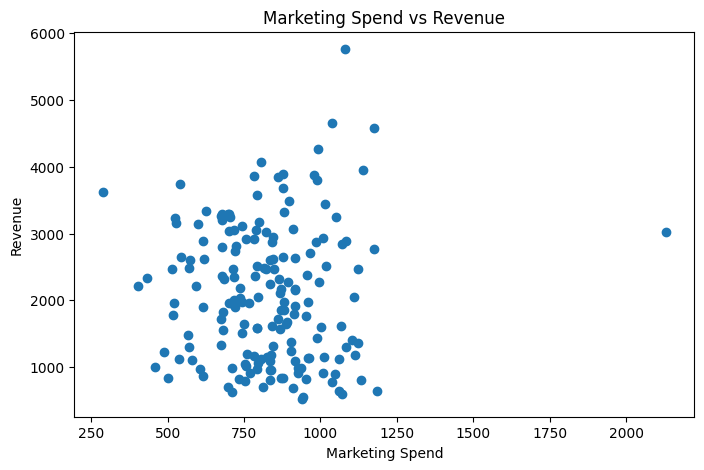

In [2]:
# Scatter plot: Marketing Spend vs Revenue
plt.figure(figsize=(8, 5))
plt.scatter(df['Marketing_Spend'], df['Revenue'])
plt.title('Marketing Spend vs Revenue')
plt.xlabel('Marketing Spend')
plt.ylabel('Revenue')
plt.show()

**Insight:** The scatter plot shows a weak relationship between marketing spend and revenue. The points are fairly spread out, which suggests that revenue depends more strongly on other factors such as product category, unit price, and quantity sold.

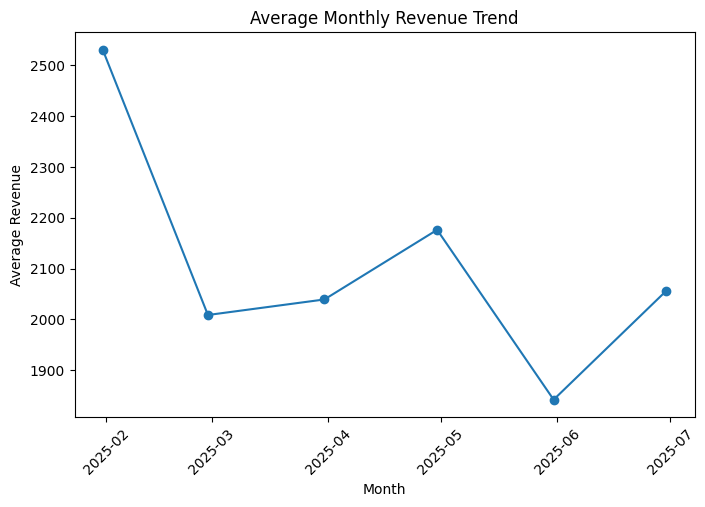

In [3]:
# Line plot: Average monthly revenue trend
monthly_revenue = df.set_index('Date')['Revenue'].resample('ME').mean()

plt.figure(figsize=(8, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Average Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.show()

**Insight:** The line plot shows that average monthly revenue remains relatively stable over time, with a noticeable high point in January and a lower point in May. This suggests the business performed consistently with only moderate month-to-month fluctuation.

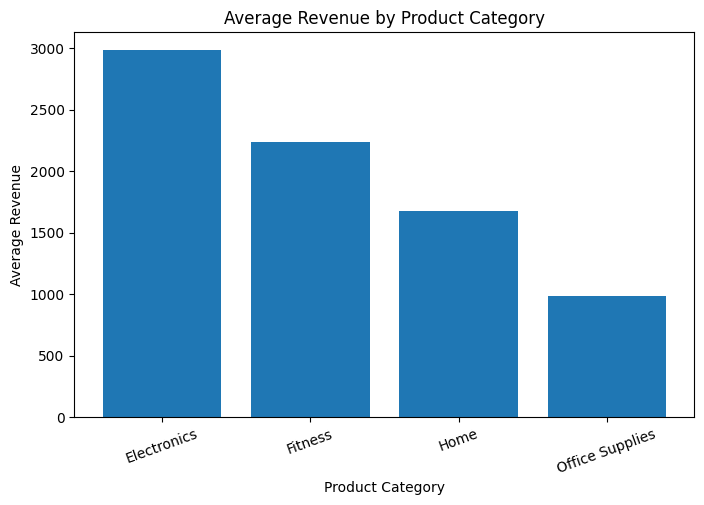

In [4]:
# Bar chart: Average revenue by product category
category_avg = df.groupby('Product_Category')['Revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(category_avg.index, category_avg.values)
plt.title('Average Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Revenue')
plt.xticks(rotation=20)
plt.show()

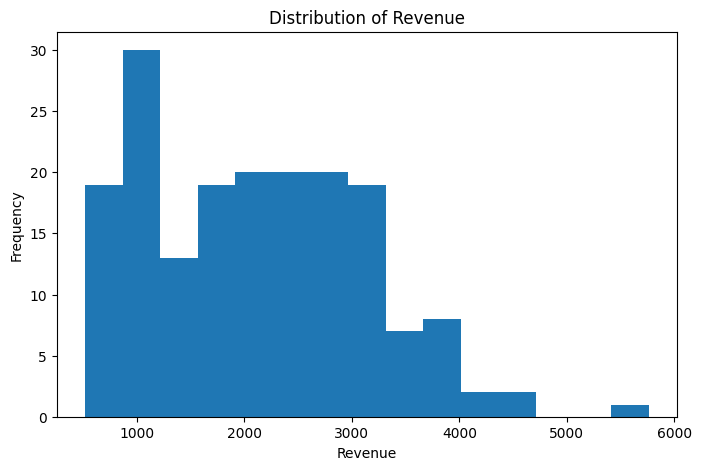

In [5]:
# Histogram: Distribution of revenue
plt.figure(figsize=(8, 5))
plt.hist(df['Revenue'], bins=15)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

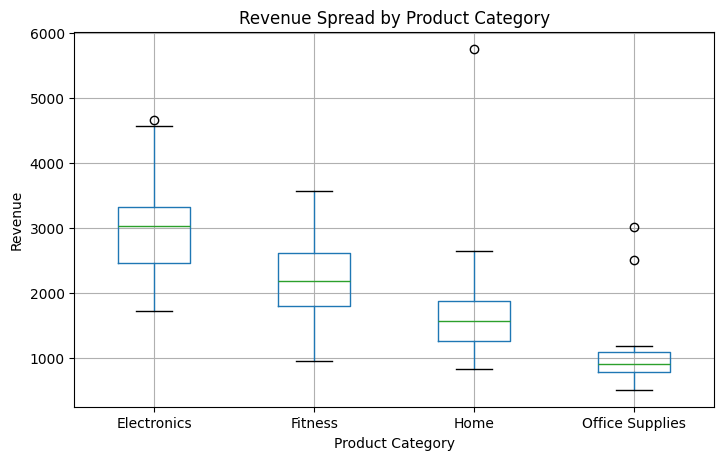

In [6]:
# Box plot: Revenue by product category
df.boxplot(column='Revenue', by='Product_Category', figsize=(8, 5))
plt.title('Revenue Spread by Product Category')
plt.suptitle('')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.show()

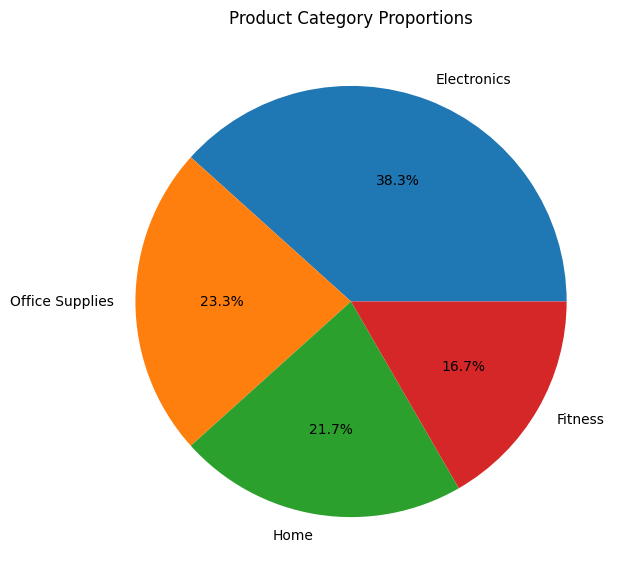

In [7]:
# Pie chart: Product category proportions
counts = df['Product_Category'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title('Product Category Proportions')
plt.show()

## Step 3: Data Preprocessing

In [8]:
# 1. Handling Missing Values
print('Missing values before handling:')
print(df.isna().sum())

df_clean = df.copy()

for col in ['Marketing_Spend', 'Customer_Rating', 'Discount_Percent']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean['Region'] = df_clean['Region'].fillna(df_clean['Region'].mode()[0])

print('\nMissing values after handling:')
print(df_clean.isna().sum())

Missing values before handling:
Date                0
Product_Category    0
Region              2
Units_Sold          0
Unit_Price          0
Discount_Percent    2
Marketing_Spend     4
Customer_Rating     3
Revenue             0
Returned_Units      0
dtype: int64

Missing values after handling:
Date                0
Product_Category    0
Region              0
Units_Sold          0
Unit_Price          0
Discount_Percent    0
Marketing_Spend     0
Customer_Rating     0
Revenue             0
Returned_Units      0
dtype: int64


Missing values were handled by replacing numeric missing values with the median and the missing categorical values in `Region` with the mode. This approach keeps the dataset complete without losing too many records.

In [9]:
# 2. Outlier Detection and Removal using IQR on Revenue
Q1 = df_clean['Revenue'].quantile(0.25)
Q3 = df_clean['Revenue'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Revenue'] < lower_bound) | (df_clean['Revenue'] > upper_bound)]

print('Q1:', round(Q1, 2))
print('Q3:', round(Q3, 2))
print('IQR:', round(IQR, 2))
print('Lower Bound:', round(lower_bound, 2))
print('Upper Bound:', round(upper_bound, 2))

print('\nIdentified outliers:')
print(outliers[['Date', 'Product_Category', 'Revenue']])

df_no_outliers = df_clean[(df_clean['Revenue'] >= lower_bound) & (df_clean['Revenue'] <= upper_bound)]

print('\nShape before removing outliers:', df_clean.shape)
print('Shape after removing outliers:', df_no_outliers.shape)

Q1: 1157.66
Q3: 2881.77
IQR: 1724.1
Lower Bound: -1428.49
Upper Bound: 5467.93

Identified outliers:
         Date Product_Category   Revenue
18 2025-01-19             Home  5760.672

Shape before removing outliers: (180, 10)
Shape after removing outliers: (179, 10)


The IQR method identified unusually high revenue values as outliers. After removing those records, the dataset became slightly smaller and more suitable for later analysis.

In [10]:
# 3. Data Reduction
print('Shape before reduction:', df_no_outliers.shape)

sampled_df = df_no_outliers.sample(frac=0.6, random_state=42).sort_values('Date').reset_index(drop=True)
reduced_df = sampled_df.drop(columns=['Returned_Units'])

print('Shape after sampling:', sampled_df.shape)
print('Shape after dropping a less relevant column:', reduced_df.shape)

print('\nBefore reduction:')
print(df_no_outliers.head())

print('\nAfter reduction:')
print(reduced_df.head())

Shape before reduction: (179, 10)
Shape after sampling: (107, 10)
Shape after dropping a less relevant column: (107, 9)

Before reduction:
        Date Product_Category Region  ...  Customer_Rating  Revenue  Returned_Units
0 2025-01-01             Home   West  ...             4.07  1980.99               3
1 2025-01-02  Office Supplies  North  ...             4.08   951.16               1
2 2025-01-03          Fitness  North  ...             4.43  2942.99               6
3 2025-01-04          Fitness  South  ...             4.12  2894.92               1
4 2025-01-05      Electronics   East  ...             4.43  3869.28               3

[5 rows x 10 columns]

After reduction:
        Date Product_Category Region  ...  Marketing_Spend  Customer_Rating  Revenue
0 2025-01-01             Home   West  ...           744.60             4.07  1980.99
1 2025-01-03          Fitness  North  ...           844.89             4.43  2942.99
2 2025-01-05      Electronics   East  ...           782.85   

Data reduction was completed by keeping 60% of the cleaned data and removing the `Returned_Units` column. This step reduces size and complexity while preserving the most relevant attributes for analysis.

In [11]:
# 4. Data Scaling and Discretization
scaled_df = reduced_df.copy()

scaler = MinMaxScaler()
scaled_df[['Revenue_Scaled', 'Marketing_Spend_Scaled']] = scaler.fit_transform(
    scaled_df[['Revenue', 'Marketing_Spend']]
)

scaled_df['Rating_Level'] = pd.cut(
    scaled_df['Customer_Rating'],
    bins=[0, 3.5, 4.2, 5.0],
    labels=['Needs Improvement', 'Good', 'Excellent'],
    include_lowest=True
)

print('Before scaling/discretization:')
print(reduced_df[['Revenue', 'Marketing_Spend', 'Customer_Rating']].head())

print('\nAfter scaling/discretization:')
print(scaled_df[['Revenue_Scaled', 'Marketing_Spend_Scaled', 'Rating_Level']].head())

Before scaling/discretization:
   Revenue  Marketing_Spend  Customer_Rating
0  1980.99           744.60             4.07
1  2942.99           844.89             4.43
2  3869.28           782.85             4.43
3  3069.32           909.42             4.14
4   960.19           834.94             4.26

After scaling/discretization:
   Revenue_Scaled  Marketing_Spend_Scaled Rating_Level
0        0.354065                0.248058         Good
1        0.593664                0.302455    Excellent
2        0.824368                0.268805    Excellent
3        0.625128                0.337456         Good
4        0.099822                0.297058    Excellent


Min-Max scaling was applied to revenue and marketing spend so both variables could be compared on the same scale. Customer ratings were also discretized into meaningful categories to simplify interpretation.

## Step 4: Statistical Analysis

In [12]:
# 1. General overview of the data
df_no_outliers.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179 entries, 0 to 179
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              179 non-null    datetime64[ns]
 1   Product_Category  179 non-null    object        
 2   Region            179 non-null    object        
 3   Units_Sold        179 non-null    int64         
 4   Unit_Price        179 non-null    float64       
 5   Discount_Percent  179 non-null    float64       
 6   Marketing_Spend   179 non-null    float64       
 7   Customer_Rating   179 non-null    float64       
 8   Revenue           179 non-null    float64       
 9   Returned_Units    179 non-null    int64         
dtypes: datetime64[ns](1), float64(5), int64(2), object(2)
memory usage: 15.4+ KB


In [13]:
df_no_outliers.describe(include='all')

,Date,Product_Category,Region,Units_Sold,Unit_Price,Discount_Percent,Marketing_Spend,Customer_Rating,Revenue,Returned_Units
count,179,179,179,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000,179.000000
unique,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Electronics,West,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,69,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-03-31 21:35:11.731843584,NaN,NaN,27.849162,83.451620,10.859553,825.372179,4.121341,2090.322425,2.474860
min,2025-01-01 00:00:00,NaN,NaN,13.000000,27.580000,0.800000,287.260000,2.800000,518.910000,0.000000
25%,2025-02-15 12:00:00,NaN,NaN,24.000000,57.835000,7.295000,712.010000,3.785000,1155.290000,1.000000
50%,2025-04-01 00:00:00,NaN,NaN,28.000000,89.300000,10.905000,834.265000,4.120000,2002.340000,2.000000
75%,2025-05-15 12:00:00,NaN,NaN,31.000000,116.670000,13.915000,926.650000,4.405000,2875.335000,3.000000
max,2025-06-29 00:00:00,NaN,NaN,43.000000,143.480000,23.160000,2130.940000,5.000000,4663.220000,9.000000


In [14]:
# 2. Central tendency measures
numeric_df = df_no_outliers.select_dtypes(include='number')

central_tendency = pd.DataFrame({
    'Minimum': numeric_df.min(),
    'Maximum': numeric_df.max(),
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Mode': numeric_df.mode().iloc[0]
}).round(2)

central_tendency

,Minimum,Maximum,Mean,Median,Mode
Units_Sold,13.00,43.00,27.85,28.00,27.00
Unit_Price,27.58,143.48,83.45,89.30,39.91
Discount_Percent,0.80,23.16,10.86,10.90,9.83
Marketing_Spend,287.26,2130.94,825.37,834.27,834.27
Customer_Rating,2.80,5.00,4.12,4.12,4.12
Revenue,518.91,4663.22,2090.32,2002.34,518.91
Returned_Units,0.00,9.00,2.47,2.00,3.00


In [15]:
# 3. Dispersion measures
dispersion = pd.DataFrame({
    'Range': numeric_df.max() - numeric_df.min(),
    'Q1': numeric_df.quantile(0.25),
    'Q3': numeric_df.quantile(0.75),
    'IQR': numeric_df.quantile(0.75) - numeric_df.quantile(0.25),
    'Variance': numeric_df.var(),
    'Standard_Deviation': numeric_df.std()
}).round(2)

dispersion

,Range,Q1,Q3,IQR,Variance,Standard_Deviation
Units_Sold,30.00,24.00,31.00,7.00,30.99,5.57
Unit_Price,115.90,57.84,116.67,58.83,1210.44,34.79
Discount_Percent,22.36,7.30,13.92,6.62,22.86,4.78
Marketing_Spend,1843.68,712.01,926.65,214.64,38661.11,196.62
Customer_Rating,2.20,3.78,4.40,0.62,0.20,0.45
Revenue,4144.31,1155.29,2875.34,1720.04,962883.41,981.27
Returned_Units,9.00,1.00,3.00,2.00,2.82,1.68


In [16]:
# 4. Correlation analysis
correlation_matrix = numeric_df.corr().round(3)
correlation_matrix

,Units_Sold,Unit_Price,Discount_Percent,Marketing_Spend,Customer_Rating,Revenue,Returned_Units
Units_Sold,1.000,-0.043,-0.172,-0.056,0.009,0.407,-0.067
Unit_Price,-0.043,1.000,-0.042,-0.125,0.181,0.847,-0.137
Discount_Percent,-0.172,-0.042,1.000,-0.009,0.058,-0.209,-0.076
Marketing_Spend,-0.056,-0.125,-0.009,1.000,-0.013,-0.013,0.017
Customer_Rating,0.009,0.181,0.058,-0.013,1.000,0.185,-0.553
Revenue,0.407,0.847,-0.209,-0.013,0.185,1.000,-0.144
Returned_Units,-0.067,-0.137,-0.076,0.017,-0.553,-0.144,1.000


### Summary of Findings

This lab showed how visualization, preprocessing, and statistical analysis work together in a practical workflow. The visualizations revealed that revenue stayed fairly stable over time, product categories performed differently, and marketing spend alone did not strongly explain revenue in this dataset. The preprocessing steps improved data quality by filling missing values, removing outliers, reducing data size, and scaling important variables. Finally, the statistical analysis summarized the dataset with descriptive measures and correlation values, making the overall structure of the data easier to understand.